In [222]:
#Importar librerias
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

In [223]:
import kagglehub

import os

# Cargar el dataset desde KaggleHub

path = kagglehub.dataset_download("tamber/steam-video-games")

#mostrarme los archivos dentros de la carpeta
os.listdir(path)



Using Colab cache for faster access to the 'steam-video-games' dataset.


['steam-200k.csv']

1.Exploracion de datos

In [224]:
#leer el archivo indcando que no tiene nombre de columnas
df = pd.read_csv(path+"/steam-200k.csv", header=None)
df.head()


,0,1,2,3,4
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0


In [225]:
#ver informacion del archivo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       200000 non-null  int64  
 1   1       200000 non-null  object 
 2   2       200000 non-null  object 
 3   3       200000 non-null  float64
 4   4       200000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.6+ MB


In [226]:
#crear una copia
df1=df.copy()

In [227]:
#dar nombre a las columnas
df1.columns = [
    "usuario",
    "juego",
    "accion",
    "horas",
    "extra"
]

In [228]:
#verificar datos nulos
df1.isnull().sum()

,0
usuario,0
juego,0
accion,0
horas,0
extra,0


In [229]:
#ver filas y columnas
df1.shape

(200000, 5)

In [230]:
#verificar datos
df1.describe (include="all")

,usuario,juego,accion,horas,extra
count,2.000000e+05,200000,200000,200000.000000,200000.0
unique,NaN,5155,2,NaN,NaN
top,NaN,Dota 2,purchase,NaN,NaN
freq,NaN,9682,129511,NaN,NaN
mean,1.036559e+08,NaN,NaN,17.874384,0.0
std,7.208074e+07,NaN,NaN,138.056952,0.0
min,5.250000e+03,NaN,NaN,0.100000,0.0
25%,4.738420e+07,NaN,NaN,1.000000,0.0
50%,8.691201e+07,NaN,NaN,1.000000,0.0
75%,1.542309e+08,NaN,NaN,1.300000,0.0


In [231]:
#ver duplicados
df1.duplicated().sum()

np.int64(707)

In [232]:
#eliminar duplicados
df1 = df1.drop_duplicates()

2. Preparación de los datos

In [233]:
#eliminar columna
#La columna extra siempre vale 0 en este dataset, por lo que no aporta información para diferenciar usuarios y se elimina antes del modelado.
df1 = df1.drop(columns="extra")

In [234]:
#crear variable
usuarios = df1.groupby("usuario").agg(
    juegos_diferentes=("juego", "nunique")
)

usuarios.head()


,juegos_diferentes
usuario,
5250,21
76767,36
86540,82
103360,10
144736,8


In [235]:
#filtrar play
jugadas = df1[df1["accion"] == "play"]

In [236]:
# Se suman las horas jugadas para obtener el tiempo total de juego de cada usuario
horas = jugadas.groupby("usuario").agg(
    horas_totales=("horas", "sum")
)
horas.head()

,horas_totales
usuario,
5250,225.5
76767,1227.0
86540,255.0
144736,0.1
181212,2.2


In [237]:
#crear variables representativas por usuario
usuarios = df1.groupby("usuario").agg(
    juegos_diferentes=("juego","nunique")
)

In [238]:
#Se cuenta el número de compras realizadas por cada usuario.
#filtrar
compras_df = df1[df1["accion"] == "purchase"]

In [239]:
#crear variable
compras = compras_df.groupby("usuario").agg(
    compras=("accion", "count")
)

In [240]:
compras.head()

,compras
usuario,
5250,21
76767,36
86540,82
103360,10
144736,8


In [241]:
#unir tablas
usuarios = usuarios.merge(horas, on="usuario")
usuarios.head()

,juegos_diferentes,horas_totales
usuario,,
5250,21,225.5
76767,36,1227.0
86540,82,255.0
144736,8,0.1
181212,12,2.2


In [242]:
usuarios = usuarios.merge(compras, on="usuario")
usuarios.head()

,juegos_diferentes,horas_totales,compras
usuario,,,
5250,21,225.5,21
76767,36,1227.0,36
86540,82,255.0,82
144736,8,0.1,8
181212,12,2.2,12


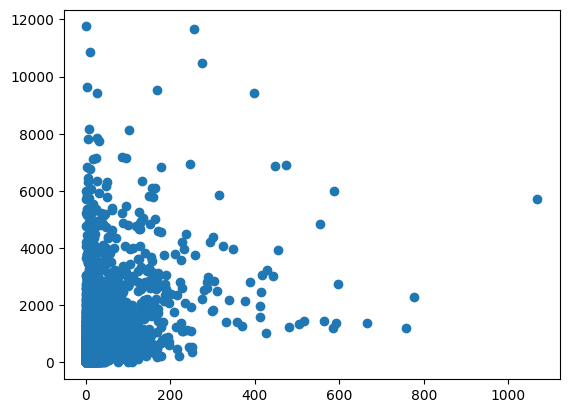

In [243]:
plt.scatter(
    usuarios["juegos_diferentes"],
    usuarios["horas_totales"]
)

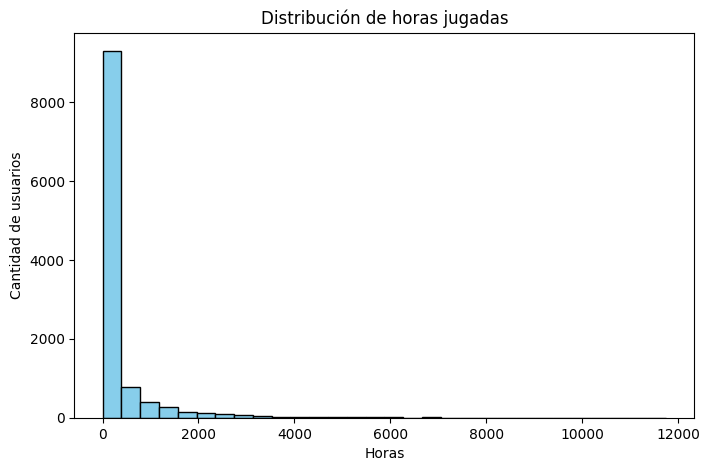

In [244]:
#visualizaciones
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(usuarios["horas_totales"],
         bins=30,
         color="skyblue",
         edgecolor="black")

plt.title("Distribución de horas jugadas")
plt.xlabel("Horas")
plt.ylabel("Cantidad de usuarios")

plt.show()

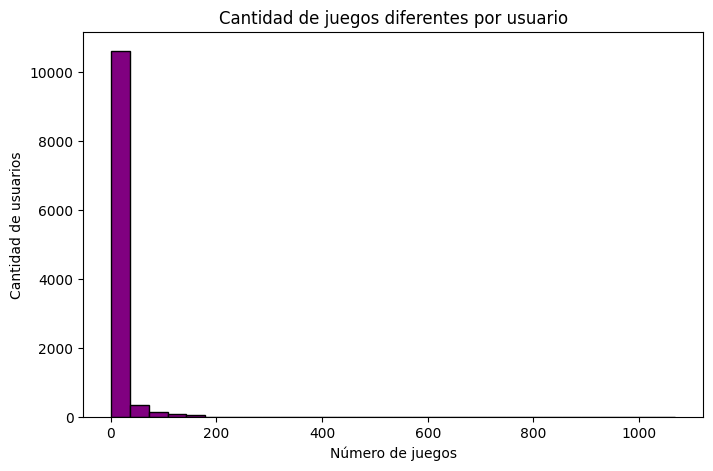

In [245]:
plt.figure(figsize=(8,5))

plt.hist(usuarios["juegos_diferentes"],
         bins=30,
         color="purple",
         edgecolor="black"
         )

plt.title("Cantidad de juegos diferentes por usuario")
plt.xlabel("Número de juegos")
plt.ylabel("Cantidad de usuarios")

plt.show()

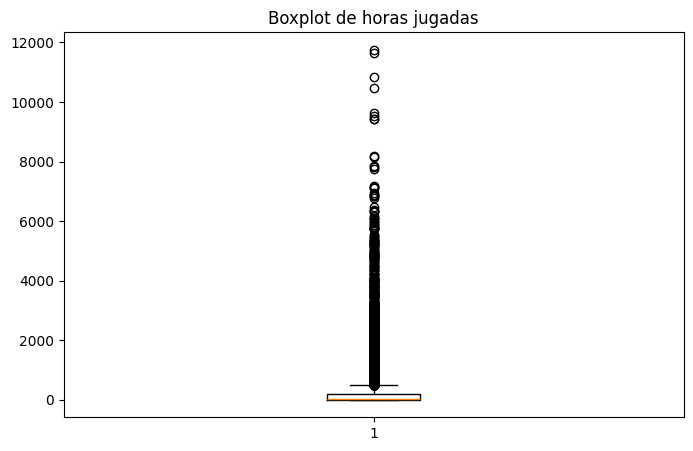

In [246]:
plt.figure(figsize=(8,5))

plt.boxplot(usuarios["horas_totales"])

plt.title("Boxplot de horas jugadas")

plt.show()

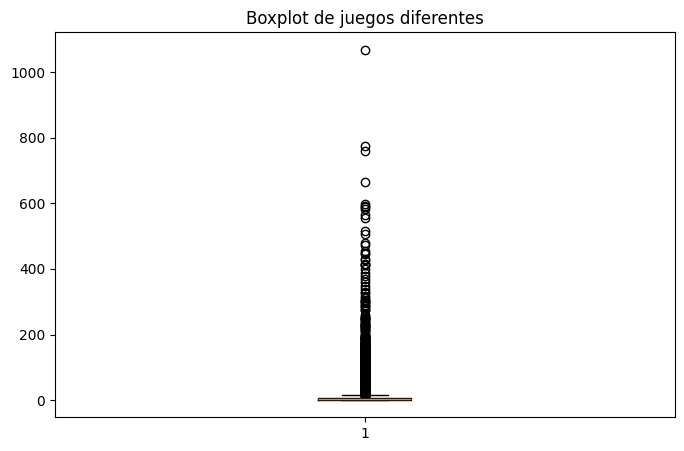

In [247]:
plt.figure(figsize=(8,5))

plt.boxplot(usuarios["juegos_diferentes"])

plt.title("Boxplot de juegos diferentes")

plt.show()

3. Modelado

In [248]:
#escalamiento
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [249]:
datos_escalados = scaler.fit_transform(
    usuarios[
        [
            "juegos_diferentes",
            "horas_totales",
            "compras"
        ]
    ]
)


In [250]:
#convertirlo a datframe
datos_escalados = pd.DataFrame(
    datos_escalados,
    columns=[
        "juegos_diferentes",
        "horas_totales",
        "compras"
    ]
)

datos_escalados.head()

,juegos_diferentes,horas_totales,compras
0,0.266139,-0.098867,0.266139
1,0.670128,1.169646,0.670128
2,1.909028,-0.061502,1.909028
3,-0.083985,-0.384362,-0.083985
4,0.023746,-0.381702,0.023746


4.Interpretacion de clusters

Se seleccionó el algoritmo K-Means porque permite agrupar usuarios con características similares de forma sencilla y eficiente. En este proyecto las variables utilizadas (cantidad de juegos diferentes, horas totales jugadas y número de compras) son variables numéricas, lo que hace que K-Means sea una técnica adecuada para identificar segmentos de usuarios con comportamientos similares.

In [251]:
# importamos k'means
from sklearn.cluster import KMeans

In [252]:
#creamos una lista vacia
inercia = []

In [253]:
for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42
    )

    modelo.fit(datos_escalados)

    inercia.append(modelo.inertia_)

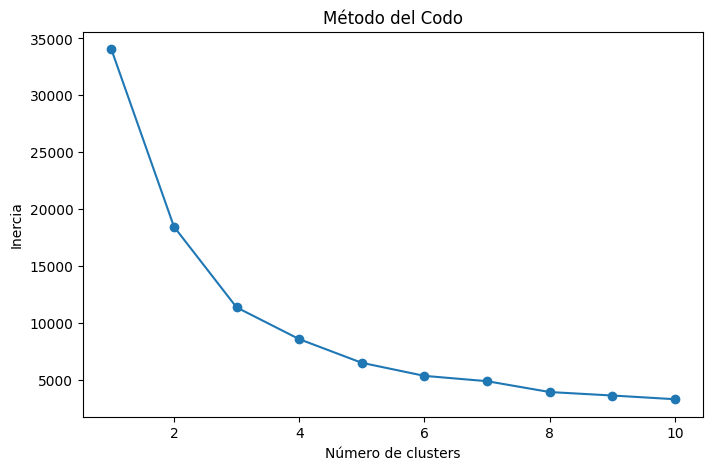

In [254]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inercia, marker="o")

plt.title("Método del Codo")

plt.xlabel("Número de clusters")

plt.ylabel("Inercia")

plt.show()

Se utilizó el método del codo para determinar el número adecuado de clústeres. Se observó que la disminución de la inercia es considerable hasta K=4. A partir de este punto, la reducción del error es menor, indicando que agregar más clústeres aporta pocas mejoras al modelo. Por esta razón se seleccionó K=4."

In [255]:
# crear cluster
kmeans = KMeans(n_clusters=4, random_state=42)

usuarios["cluster"] = kmeans.fit_predict(datos_escalados)

In [256]:
usuarios.groupby("cluster").mean(numeric_only=True)


,juegos_diferentes,horas_totales,compras
cluster,,,
0,5.118667,125.165329,5.118667
1,140.215278,1947.568750,140.215278
2,489.121212,3060.681818,489.121212
3,27.595238,2511.245408,27.595238


🎮 Cluster 0 – Jugadores Casuales

*Características
Poseen pocos videojuegos.
Compran pocos juegos.
Juegan pocas horas.

*Tipo de jugador
Jugadores ocasionales.

*Comportamiento de compra
Realizan pocas compras y juegan de forma esporádica.

*Estrategia
Promocionar la plataforma.

*Promociones
Juegos gratuitos.
Promociones de fin de semana.
Marketing digital

🛒 Cluster 1 – Compradores Frecuentes

*Características
Amplia coleccion  de videojuegos.
Muchas compras realizadas.
Alto número de horas jugadas.

*Tipo de jugador
Jugadores frecuentes.

*Comportamiento de compra
Compran videojuegos con regularidad y mantienen una actividad constante en la plataforma.

*Estrategia
Ampliar la frecuencia de compra.

*Promociones
Bonos por compras recurrentes.
Preventas.


👑 Cluster 2 –Aficionados o Gamers Expertos

*Características
Gran cantidad de videojuegos adquiridos.
Mayor número de compras.
Mayor cantidad de horas jugadas.

*Tipo de jugador
Usuarios muy activos.

*Comportamiento de compra
Presentan el mayor nivel de consumo dentro de la plataforma y un alto compromiso con los videojuegos.

*Estrategia
Fidelización.
Mejora continua

*Promociones
Acceso anticipado.
Ediciones especiales.
Beneficios exclusivos.
Programas VIP.

🔥 Cluster 3 – Jugadores Dedicados

*Características
Pocos videojuegos en comparación con otros grupos.
Muchísimas horas acumuladas.
Se enfocan en títulos en especifico.

*Tipo de jugador
Jugadores frecuentes pero especializados.

*Comportamiento de compra
No realizan muchas compras, pero aprovechan al máximo los juegos que poseen

*Estrategia
Mantener su permanencia en la plataforma.
Aumentar horas de juego

*Promociones
Recompensas.
Contenido exclusivo del juego que más utilizan.
Mejoras visuales y auditivas en el videojuego.

Los principales factores diferenciadores entre los grupos son la cantidad de videojuegos adquiridos, el número de compras realizadas y las horas totales de juego. Mientras algunos usuarios presentan un comportamiento ocasional con pocas compras y pocas horas de juego, otros muestran un alto nivel de compromiso con la plataforma, ya sea adquiriendo una gran cantidad de videojuegos o dedicando muchas horas a pocos títulos específicos.


5. ¿Qué usuarios priorizar para campañas de fidelización?

Se priorizarían principalmente los usuarios pertenecientes a los clústeres 2 y 3. Los usuarios del clúster 2 representan el mayor valor para la plataforma debido a su alto volumen de compras y tiempo de juego. Por otro lado, los usuarios del clúster 3 muestran un alto nivel de compromiso   videojuegos especificos en cuanto a caracteristicas y/o titulos, por lo que podrían incrementar su consumo mediante recomendaciones personalizadas y promociones relacionadas con sus intereses

6. Informacion adicional

Para mejorar la segmentación sería útil contar con información especifica  sobre el género de los videojuegos, la frecuencia de juego, la fecha de compra de cada título, el país o región del usuario y variables demográficas como la edad y sexo. Esta información permitiría comprender mejor las preferencias de los jugadores y diseñar estrategias de marketing más personalizadas.